In [ ]:
from reaction_diffusion_model import *
from helper import *

import torch
import torch.nn as nn
import torch.nn.functional as F

from neurodiffeq import diff
from neurodiffeq.neurodiffeq import unsafe_diff as unsafe_diff

import numpy as np
import pickle

c:\Users\ryqhe\Desktop\iclr2026workshop\Cheby-PINNs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set up model

In [2]:
k=16
model = Multihead_model(k=k, act = nn.functional.silu, bias=True)

In [3]:
k1 = 2
K2 = np.linspace(1, 2, 8)
A_list = [0.5, -0.5]; b = 0.5; k=16

truth_functions = []; Forcing_functions = []

for k2 in K2:
  for A in A_list:
    truth_functions.append(truth_decorator_trig(A, k1, k2, b=b))
    Forcing_functions.append(forcing_decorator_trig(A, k1, k2, D=1))

#compute the truth solution
truth_solution = [truth_functions[i](X_grid[:,0], X_grid[:,1]).cpu().detach().numpy().reshape(round(X_grid.shape[0]**.5), -1) for i in range(k)]

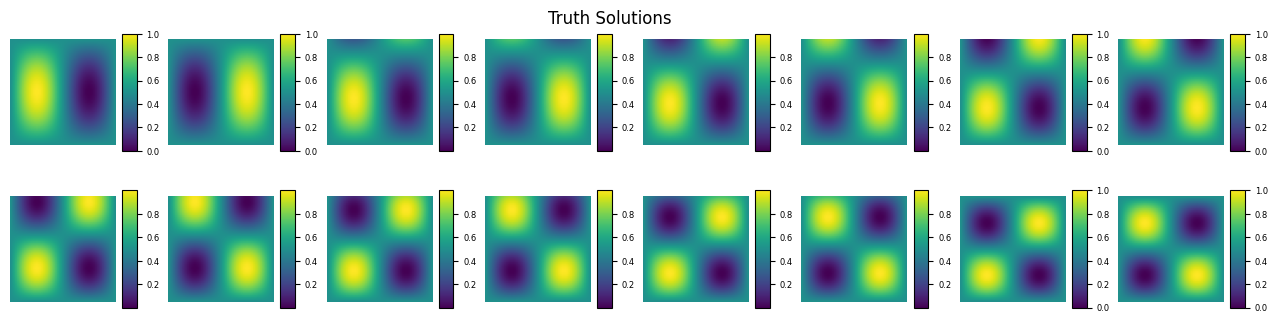

In [4]:
plot_solutions16(truth_solution, 'Truth Solutions');

In [ ]:
b = 0.5
learning_rate = 1e-3
num_iter= 20000
step_size = 100
gamma = 0.98

interior_grid = (50, 50)
x_boundary_num = 100
t_boundary_num = 100
boundary_value = b
method='equally-spaced-noisy'

pde_weight = 1; bc_weight = 1; data_weight = 1

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

## Train the model

In [ ]:
loss_trace, pde_trace, bc_trace, data_trace = train(model, optimizer, loss, num_iter, Forcing_functions, truth_functions,
          boundary_value, D = 1, interior_grid=interior_grid, x_boundary_num=x_boundary_num, t_boundary_num=t_boundary_num,
          every=100, pde_weight=pde_weight, bc_weight=bc_weight, data_weight=data_weight, scheduler=scheduler, method=method)

  0%|          | 100/20000 [00:49<2:43:32,  2.03it/s]

100th Iter: total 21.287780496396874, pde 21.21296789019865, bc 0.01964610370279553, data 0.0551665024954237


  1%|          | 200/20000 [01:38<2:40:56,  2.05it/s]

200th Iter: total 1.854355892031392, pde 1.73809918364891, bc 0.0623374654121882, data 0.05391924297029388


  2%|▏         | 300/20000 [02:27<2:41:16,  2.04it/s]

...

19800th Iter: total 0.00015941251228946795, pde 0.0001356964203710867, bc 1.8441552769557783e-05, data 5.274539148823484e-06


100%|█████████▉| 19900/20000 [2:41:54<00:48,  2.05it/s]

19900th Iter: total 0.00014974170219647856, pde 0.0001264612781206277, bc 1.812836607950583e-05, data 5.152057996345018e-06


100%|██████████| 20000/20000 [2:42:43<00:00,  2.05it/s]

20000th Iter: total 0.00014412622857574943, pde 0.00012126219269865469, bc 1.7957995104072004e-05, data 4.906040773022735e-06


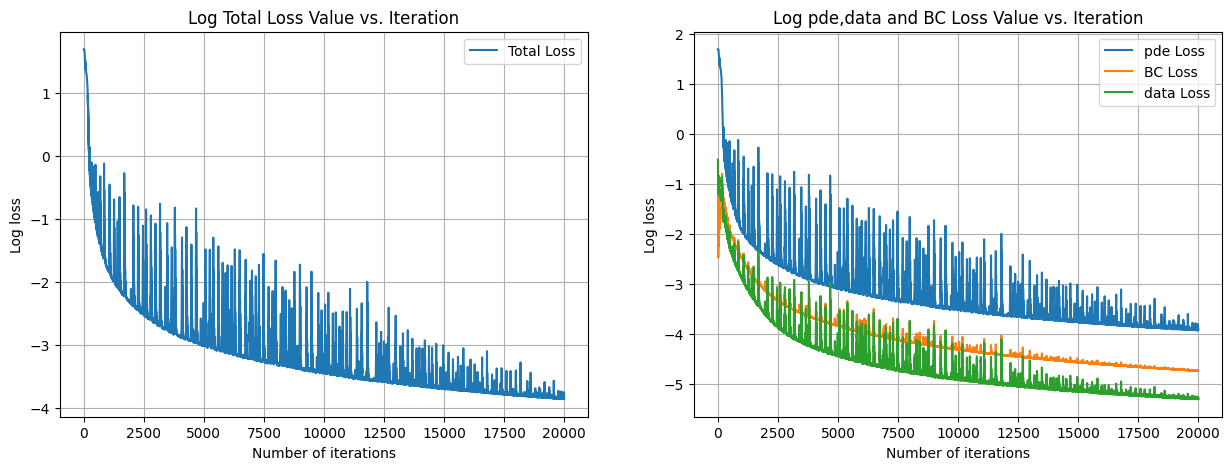

In [7]:
plot_loss(loss_trace, pde_trace, bc_trace, data_trace)

In [ ]:
NN_solution, _ = model(X_grid.to('cuda'))
NN_solution = NN_solution[:, :, 0].cpu().detach().numpy()
NN_solution = [NN_solution[i, :].reshape(round(X_grid.shape[0]**.5), -1) for i in range(k)]

In [ ]:
def relative_error(NN_solution, truth_solution):
  return abs(np.array(NN_solution) - np.array(truth_solution)).mean() / abs(np.array(truth_solution)).mean()

r_error = relative_error(NN_solution, truth_solution)
print("Relative Error: {}".format(r_error))

Relative Error: 0.003126879201784472


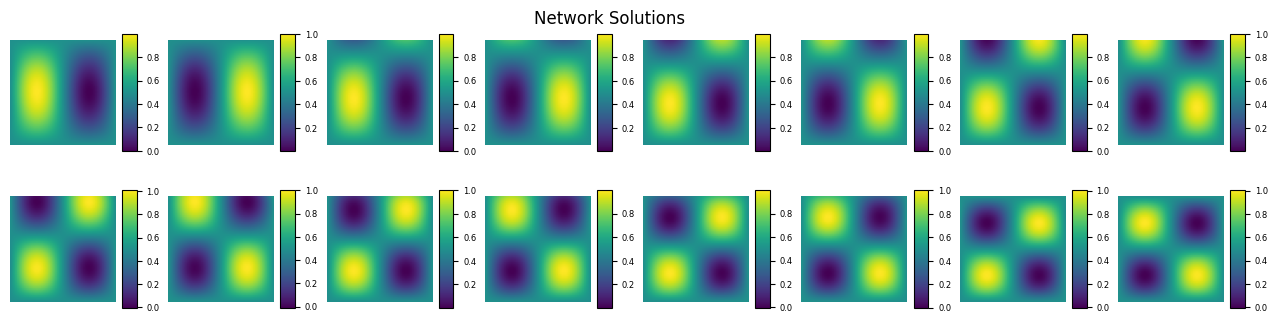

In [ ]:
plot_solutions16(NN_solution, "Network Solutions")

In [ ]:
log = {
    'model': model,
    'optimizer':optimizer,
    'bias': True,
    'forcing_info': {
        'A': A_list,
        'K1': k1,
        'K2': K2,
        'b': b
    },
    'lr': learning_rate,
    'num_iter': num_iter,
    'step_size': step_size,
    'gamma': gamma,
    'interior_grid': interior_grid,
    'x_boundary_num': x_boundary_num,
    't_boundary_num': t_boundary_num,
    'boundary_value': b,
    'pde_weight': pde_weight,
    'bc_weight': bc_weight,
    'data_weight': data_weight,
    'loss_trace': {
        'total': loss_trace,
        'pde': pde_trace,
        'bc': bc_trace,
        'data': data_trace
    },
    'relative_error': r_error,
    'method': 'equally-spaced-noisy'
}

In [ ]:
path = 'Reaction_diffusion_16head_model_trig.pickle'
file = open(path, 'wb')
pickle.dump(model.cpu(), file)
file.close()

In [ ]:
path = 'Reaction_diffusion_16head_log_trig.pickle'
file = open(path, 'wb')
pickle.dump(log, file)
file.close()